# Taller de Tesis I — Preprocesamiento
## Notebook 02: Limpieza, imputación y codificación de features

**Maestría en Data Mining — FCEyN, UBA**  
**Grupo:** G2  
**Dataset:** Stack Overflow Developer Survey 2023 + 2024 + 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
sns.set_theme(style='darkgrid', palette='muted')
print('✅ Imports OK')


✅ Imports OK


## Sección 1 — Carga y filtro de calidad

Se recargan los tres datasets crudos y se aplican las mismas normalizaciones de schema definidas en el notebook 01 (mapeo de `AISelect` en 2025, renombramiento de `YearsCodePro`, inversión `AIAcc`/`AIBen` en 2023). En esta instancia se conservan *todas* las columnas para poder seleccionar el subconjunto de features en la sección siguiente.

El filtro por `MainBranch == 'I am a developer by profession'` garantiza homogeneidad de la población: se excluyen estudiantes, aficionados y ex-desarrolladores, cuyo perfil difiere estructuralmente del adoptante profesional que es objeto de estudio.

In [2]:
# --- Carga de los tres datasets ---
df23 = pd.read_csv('../data/survey_results_public_2023.csv', low_memory=False)
df24 = pd.read_csv('../data/survey_results_public_2024.csv', low_memory=False)
df25 = pd.read_csv('../data/survey_results_public_2025.csv', low_memory=False)

df23['survey_year'] = 2023
df24['survey_year'] = 2024
df25['survey_year'] = 2025

print(f'Cargados: 2023={df23.shape[0]:,}  2024={df24.shape[0]:,}  2025={df25.shape[0]:,}')

# --- Normalización de schemas (idéntica al notebook 01) ---
aiselect_yes_2025 = [
    'Yes, I use AI tools daily',
    'Yes, I use AI tools weekly',
    'Yes, I use AI tools monthly or infrequently',
]
df25['AISelect'] = df25['AISelect'].apply(
    lambda v: 'Yes' if v in aiselect_yes_2025 else v
)

if 'YearsCodePro' not in df25.columns and 'YearsCode' in df25.columns:
    df25['YearsCodePro'] = df25['YearsCode']

# 2023: AIAcc y AIBen tienen significados invertidos respecto a 2024+
df23 = df23.rename(columns={'AIAcc': 'AIBen', 'AIBen': 'AIAcc'})

# 2025: DevEnvsHaveWorkedWith → NEWCollabToolsHaveWorkedWith
if 'DevEnvsHaveWorkedWith' in df25.columns and 'NEWCollabToolsHaveWorkedWith' not in df25.columns:
    df25 = df25.rename(columns={'DevEnvsHaveWorkedWith': 'NEWCollabToolsHaveWorkedWith'})

print('✅ Normalizaciones de schema aplicadas')


Cargados: 2023=89,184  2024=65,437  2025=49,191
✅ Normalizaciones de schema aplicadas


In [3]:
# --- Target ---
usa_ia = ['Yes']
actitud_positiva = ['Favorable', 'Very favorable']

def build_target(df):
    return (df['AISelect'].isin(usa_ia) & df['AISent'].isin(actitud_positiva)).astype(int)

df23['target'] = build_target(df23)
df24['target'] = build_target(df24)
df25['target'] = build_target(df25)

# Concat y filtro MainBranch
df_raw = pd.concat([df23, df24, df25], ignore_index=True)
n_antes = len(df_raw)

dev_label = 'I am a developer by profession'
df_raw = df_raw[df_raw['MainBranch'] == dev_label].copy()
n_despues = len(df_raw)

print(f'Antes del filtro MainBranch:   {n_antes:,} filas')
print(f'Después del filtro MainBranch: {n_despues:,} filas')
print(f'Descartadas: {n_antes - n_despues:,} ({(n_antes - n_despues)/n_antes:.1%})')
print(f'\nDistribución por año tras filtro:')
print(df_raw['survey_year'].value_counts().sort_index())


Antes del filtro MainBranch:   203,812 filas
Después del filtro MainBranch: 154,911 filas
Descartadas: 48,901 (24.0%)

Distribución por año tras filtro:
survey_year
2023    67237
2024    50207
2025    37467
Name: count, dtype: int64


In [4]:
assert len(df_raw) > 0
assert df_raw['MainBranch'].nunique() == 1
assert 'target' in df_raw.columns
print('✅ Sección 1 OK')


✅ Sección 1 OK


## Sección 2 — Selección de columnas

Se retienen únicamente las variables que representan el perfil profesional del desarrollador, excluyendo aquellas que introducirían *data leakage*, redundancia o baja señal predictiva. La decisión de exclusión se justifica individualmente en los comentarios del código.

In [5]:
COLS_KEEP = [
    'survey_year', 'target',
    'DevType', 'YearsCode', 'YearsCodePro', 'WorkExp', 'EdLevel',
    'OrgSize', 'Employment', 'RemoteWork', 'ICorPM', 'Industry', 'Country',
    'JobSat',                        # ausente en 2023 → NaN, se imputará
    'LanguageHaveWorkedWith',        # renombramos a Language
    'DatabaseHaveWorkedWith',        # renombramos a Database
    'PlatformHaveWorkedWith',        # renombramos a Platform
    'NEWCollabToolsHaveWorkedWith',  # DevEnvs en 2025, ya renombrado
]

# --- COLUMNAS EXCLUIDAS (con justificación) ---
# CompTotal:    >50% nulos y sesgo monetario entre países (PPP)
# Age:          redundante con YearsCode/WorkExp
# AITool, AINext, AIBen, AIComplex, AIThreat: data leakage (preguntas sobre IA)
# SO*:          comportamiento en la plataforma, no perfil profesional
# Currency:     proxy exacto de Country
# LearnCode*:   baja señal predictiva esperada
# CodingActivities, PurchaseInfluence, BuyNewTool, OfficeStackSync/Async: baja señal

cols_disponibles = [c for c in COLS_KEEP if c in df_raw.columns]
cols_faltantes   = [c for c in COLS_KEEP if c not in df_raw.columns]

if cols_faltantes:
    print(f'Columnas no encontradas (NaN): {cols_faltantes}')
    for col in cols_faltantes:
        df_raw[col] = np.nan

df = df_raw[COLS_KEEP].copy()

df = df.rename(columns={
    'LanguageHaveWorkedWith':       'Language',
    'DatabaseHaveWorkedWith':       'Database',
    'PlatformHaveWorkedWith':       'Platform',
    'NEWCollabToolsHaveWorkedWith': 'DevEnvs',
})

print(f'Dataset tras selección: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print('Columnas:', df.columns.tolist())


Dataset tras selección: 154,911 filas × 18 columnas
Columnas: ['survey_year', 'target', 'DevType', 'YearsCode', 'YearsCodePro', 'WorkExp', 'EdLevel', 'OrgSize', 'Employment', 'RemoteWork', 'ICorPM', 'Industry', 'Country', 'JobSat', 'Language', 'Database', 'Platform', 'DevEnvs']


In [6]:
assert 'target' in df.columns
assert 'survey_year' in df.columns
assert df.shape[1] == len(COLS_KEEP)
print('✅ Sección 2 OK')


✅ Sección 2 OK


## Sección 3 — Reporte de nulos

Antes de cualquier imputación se documenta la magnitud de datos faltantes por columna. El umbral del 40% de nulos como criterio de descarte es conservador: columnas con más de ese porcentaje ofrecen señal insuficiente para imputación robusta y pueden sesgar los modelos.

In [7]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_df = pd.DataFrame({'columna': null_pct.index, 'nulos_%': null_pct.values.round(1)})
print('=== Porcentaje de nulos por columna (antes de imputar) ===')
print(null_df.to_string(index=False))


=== Porcentaje de nulos por columna (antes de imputar) ===
     columna  nulos_%
      JobSat     65.6
    Industry     43.0
      ICorPM     38.8
     WorkExp     34.3
    Platform     31.2
    Database     22.4
     OrgSize     15.4
     DevEnvs     14.8
    Language     11.0
YearsCodePro     10.6
  RemoteWork     10.2
     Country      9.7
     DevType      6.5
   YearsCode      5.4
     EdLevel      2.5
  Employment      0.4
      target      0.0
 survey_year      0.0


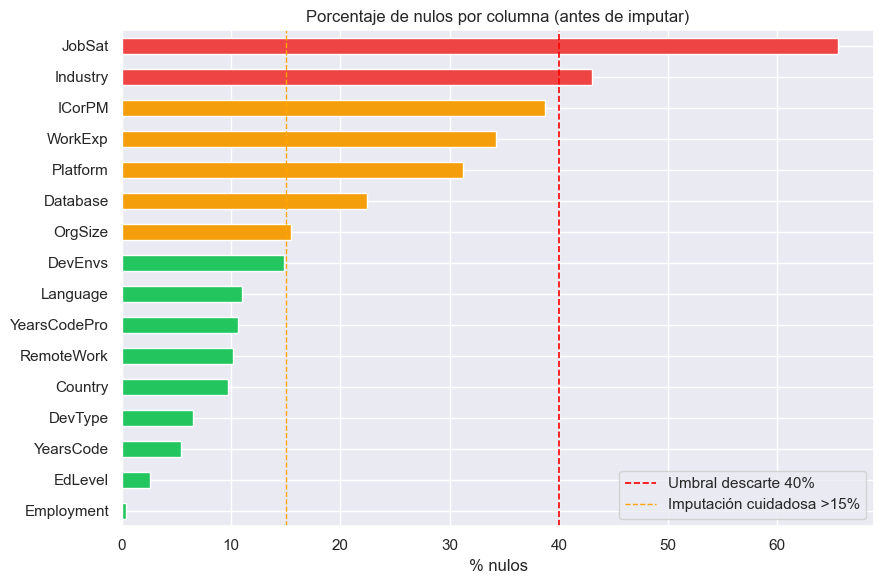

✅ Gráfico guardado en outputs/02_nulos_antes.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
null_plot = null_pct[null_pct > 0].sort_values()
colors = ['#ef4444' if v > 40 else '#f59e0b' if v > 15 else '#22c55e' for v in null_plot.values]
null_plot.plot(kind='barh', ax=ax, color=colors)
ax.axvline(40, color='red', linestyle='--', linewidth=1.2, label='Umbral descarte 40%')
ax.axvline(15, color='orange', linestyle='--', linewidth=1, label='Imputación cuidadosa >15%')
ax.set_title('Porcentaje de nulos por columna (antes de imputar)', fontsize=12)
ax.set_xlabel('% nulos')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/02_nulos_antes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado en outputs/02_nulos_antes.png')


In [9]:
UMBRAL_NULOS = 40.0
cols_a_descartar = null_pct[null_pct > UMBRAL_NULOS].index.tolist()

if cols_a_descartar:
    print(f'Columnas con >{UMBRAL_NULOS}% nulos → descartadas:')
    for col in cols_a_descartar:
        print(f'  {col}: {null_pct[col]:.1f}%')
    df = df.drop(columns=cols_a_descartar)
else:
    print(f'Ninguna columna supera el {UMBRAL_NULOS}% de nulos.')

print(f'Shape tras descarte: {df.shape}')


Columnas con >40.0% nulos → descartadas:
  JobSat: 65.6%
  Industry: 43.0%
Shape tras descarte: (154911, 16)


In [10]:
remaining_nulls = (df.isnull().sum() / len(df) * 100)
assert remaining_nulls.max() <= UMBRAL_NULOS + 0.1
print('✅ Sección 3 OK')


✅ Sección 3 OK


## Sección 4 — Tratamiento de nulos

La estrategia de imputación se diferencia según la naturaleza de cada variable:

- **Ordinales** (experiencia, educación, tamaño de org): mediana por año de encuesta, para preservar la distribución real de cada cohorte.
- **Nominales** (modalidad de trabajo, rol, empleo, industria): moda global.
- **Multi-valor** (lenguajes, bases de datos, plataformas): `NaN` → `''`, que semánticamente equivale a 'no listó ninguna tecnología'.
- **JobSat**: escala numérica 1–10, ausente en 2023. Se imputa con la mediana de 2024+2025.
- **DevType**: `NaN` → `'Other'`.

In [11]:
# Multi-valor: NaN → '' (ausencia de tecnologías listadas, no es dato faltante)
multi_val_cols = [c for c in ['Language', 'Database', 'Platform', 'DevEnvs'] if c in df.columns]
for col in multi_val_cols:
    df[col] = df[col].fillna('')
print(f"Multi-valor rellenados con '': {multi_val_cols}")


Multi-valor rellenados con '': ['Language', 'Database', 'Platform', 'DevEnvs']


In [12]:
# DevType: NaN → 'Other'
if 'DevType' in df.columns:
    n = df['DevType'].isna().sum()
    df['DevType'] = df['DevType'].fillna('Other')
    print(f'DevType: {n:,} NaN → "Other"')


DevType: 10,070 NaN → "Other"


In [13]:
# Nominales: moda global
nominales = [c for c in ['RemoteWork', 'ICorPM', 'Employment', 'Industry'] if c in df.columns]
for col in nominales:
    moda = df[col].mode()[0]
    n = df[col].isna().sum()
    df[col] = df[col].fillna(moda)
    print(f'{col}: {n:,} NaN → moda="{moda}"')


RemoteWork: 15,769 NaN → moda="Remote"
ICorPM: 60,037 NaN → moda="Individual contributor"
Employment: 602 NaN → moda="Employed, full-time"


In [14]:
# JobSat: numérico 1-10, ausente en 2023 → mediana de 2024+2025
if 'JobSat' in df.columns:
    df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')
    mediana_js = df['JobSat'].median()
    n = df['JobSat'].isna().sum()
    df['JobSat'] = df['JobSat'].fillna(mediana_js)
    print(f'JobSat: {n:,} NaN → mediana={mediana_js:.1f}')


In [15]:
# WorkExp: numérico (slider/TE) → mediana por año
if 'WorkExp' in df.columns:
    df['WorkExp'] = pd.to_numeric(df['WorkExp'], errors='coerce')
    for year in sorted(df['survey_year'].unique()):
        mask = (df['survey_year'] == year) & df['WorkExp'].isna()
        if mask.sum() > 0:
            med = df.loc[df['survey_year'] == year, 'WorkExp'].median()
            df.loc[mask, 'WorkExp'] = med
            print(f'WorkExp {year}: {mask.sum():,} NaN → mediana={med:.1f}')

print('\nNulos restantes:')
resto = df.isnull().sum()
print(resto[resto > 0] if resto.sum() > 0 else 'ninguno')


WorkExp 2023: 27,416 NaN → mediana=9.0
WorkExp 2024: 23,127 NaN → mediana=9.0
WorkExp 2025: 2,520 NaN → mediana=10.0

Nulos restantes:
YearsCode        8327
YearsCodePro    16428
EdLevel          3933
OrgSize         23913
Country         15091
dtype: int64


In [16]:
for col in multi_val_cols + nominales + (['JobSat'] if 'JobSat' in df.columns else []):
    assert df[col].isna().sum() == 0, f'Todavía hay NaN en {col}'
print('✅ Sección 4 OK')


✅ Sección 4 OK


## Sección 5 — Encoding de variables ordinales

Las variables ordinales de texto se codifican numéricamente respetando su orden lógico. Este encoding preserva la información de distancia relativa entre categorías, relevante tanto para modelos de árbol como para análisis de correlación en el EDA.

In [17]:
# Mapeo para YearsCode y YearsCodePro
YEARS_MAP = {
    'Less than 1 year': 0,
    '1 to 4 years': 2,
    '5 to 9 years': 7,
    '10 to 14 years': 12,
    '15 to 19 years': 17,
    '20 to 24 years': 22,
    '25 to 29 years': 27,
    '30 to 34 years': 32,
    '35 to 39 years': 37,
    '40 to 44 years': 42,
    '45 to 49 years': 47,
    'More than 50 years': 52,
}

for col in ['YearsCode', 'YearsCodePro']:
    if col not in df.columns:
        continue
    # Convertir a numérico directo (años que ya son número o '1 to 4 years' → NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Para los NaN que originaban de strings del mapa, recuperar el original
    orig_col = df_raw[col] if col in df_raw.columns else None
    if orig_col is not None:
        orig_aligned = orig_col.reindex(df.index)
        texto_mask = df[col].isna() & orig_aligned.isin(YEARS_MAP.keys())
        df.loc[texto_mask, col] = orig_aligned[texto_mask].map(YEARS_MAP)
    # Imputar NaN restantes con mediana por año
    for year in sorted(df['survey_year'].unique()):
        mask = (df['survey_year'] == year) & df[col].isna()
        if mask.sum() > 0:
            med = df.loc[df['survey_year'] == year, col].median()
            df.loc[mask, col] = med
    print(f'{col}: rango [{df[col].min():.0f}, {df[col].max():.0f}], NaN={df[col].isna().sum()}')


YearsCode: rango [0, 100], NaN=0


YearsCodePro: rango [0, 100], NaN=0


In [18]:
EDLEVEL_MAP = {
    'Primary/elementary school': 0,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 1,
    'Some college/university study without earning a degree': 2,
    'Associate degree (e.g. AA, AS)': 3,
    'Associate degree (A.A., A.S., etc.)': 3,
    "Bachelor's degree (e.g. BA, BS)": 4,
    "Bachelor's degree (B.A., B.S., M.S., etc.)": 4,
    "Master's degree (e.g. MA, MS, MEng, MBA)": 5,
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    'Professional degree (e.g. JD, MD, Ph.D, Ed.D)': 6,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 6,
    'Other doctoral degree (e.g. Ph.D, EdD, etc.)': 6,
    'Something else': np.nan,
}

if 'EdLevel' in df.columns:
    df['EdLevel'] = df['EdLevel'].map(EDLEVEL_MAP)
    for year in sorted(df['survey_year'].unique()):
        mask = (df['survey_year'] == year) & df['EdLevel'].isna()
        if mask.sum() > 0:
            med = df.loc[df['survey_year'] == year, 'EdLevel'].median()
            df.loc[mask, 'EdLevel'] = med
    print(f'EdLevel: rango [{df["EdLevel"].min():.0f}, {df["EdLevel"].max():.0f}], NaN={df["EdLevel"].isna().sum()}')


EdLevel: rango [0, 6], NaN=0


In [19]:
ORGSIZE_MAP = {
    'Just me - I am a freelancer, contractor, etc.': 0,
    'Just me': 0,
    '2 to 9 employees': 1,
    'Smaller than 10 employees': 1,
    '10 to 19 employees': 2,
    '20 to 99 employees': 3,
    '100 to 499 employees': 4,
    '500 to 999 employees': 5,
    '1,000 to 4,999 employees': 6,
    '5,000 to 9,999 employees': 7,
    '10,000 or more employees': 8,
    'I prefer not to answer': np.nan,
}

if 'OrgSize' in df.columns:
    df['OrgSize'] = df['OrgSize'].map(ORGSIZE_MAP)
    for year in sorted(df['survey_year'].unique()):
        mask = (df['survey_year'] == year) & df['OrgSize'].isna()
        if mask.sum() > 0:
            med = df.loc[df['survey_year'] == year, 'OrgSize'].median()
            df.loc[mask, 'OrgSize'] = med
    print(f'OrgSize: rango [{df["OrgSize"].min():.0f}, {df["OrgSize"].max():.0f}], NaN={df["OrgSize"].isna().sum()}')


OrgSize: rango [1, 8], NaN=0


In [20]:
for col in ['YearsCode', 'YearsCodePro', 'EdLevel', 'OrgSize', 'WorkExp']:
    if col in df.columns:
        assert pd.api.types.is_numeric_dtype(df[col]), f'{col} no es numérico'
        assert df[col].isna().sum() == 0, f'{col} tiene NaN'
print('✅ Sección 5 OK')


✅ Sección 5 OK


## Sección 6 — Variables multi-valor: binarización

Las variables de tecnologías almacenan múltiples valores separados por punto y coma. Se aplica una binarización manual sobre los *top-N* ítems más frecuentes (top-20 para lenguajes, top-10 para el resto), descartando la cola larga de tecnologías de baja cobertura. Se genera también una columna `{col}_count` con la cantidad total de tecnologías listadas, que captura la amplitud del stack tecnológico.

In [21]:
def binarize_multival(df, col, top_n, prefix):
    # Conteo de items por fila
    df[f'{prefix}_count'] = df[col].apply(
        lambda x: len([v.strip() for v in x.split(';') if v.strip()]) if x else 0
    )
    # Frecuencia global
    counter = Counter()
    for row in df[col]:
        if row:
            for v in row.split(';'):
                v = v.strip()
                if v:
                    counter[v] += 1
    top_items = [item for item, _ in counter.most_common(top_n)]
    print(f'{col}: top-{top_n} items → {len(top_items)} columnas binarias')
    for item in top_items:
        safe = item.replace(' ', '_').replace('/', '_').replace('.', '').replace('-', '_').replace('+', 'plus')[:30]
        col_name = f'{prefix}_{safe}'
        item_set = item  # closure
        df[col_name] = df[col].apply(
            lambda x: 1 if x and item_set in [v.strip() for v in x.split(';')] else 0
        )
    return df

TOP_N  = {'Language': 20, 'Database': 10, 'Platform': 10, 'DevEnvs': 10}
PREFIX = {'Language': 'lang', 'Database': 'db', 'Platform': 'plat', 'DevEnvs': 'env'}

for col, top_n in TOP_N.items():
    if col in df.columns:
        df = binarize_multival(df, col, top_n, PREFIX[col])
        df = df.drop(columns=[col])

print(f'\nShape tras binarización: {df.shape}')


Language: top-20 items → 20 columnas binarias


Database: top-10 items → 10 columnas binarias


Platform: top-10 items → 10 columnas binarias


DevEnvs: top-10 items → 10 columnas binarias



Shape tras binarización: (154911, 66)


In [22]:
for col in ['Language', 'Database', 'Platform', 'DevEnvs']:
    assert col not in df.columns, f'Columna de texto {col} todavía presente'
for col in [c for c in df.columns if c.endswith('_count')]:
    assert df[col].min() >= 0
print('✅ Sección 6 OK')


✅ Sección 6 OK


## Sección 7 — Country → regiones

La variable `Country` tiene alta cardinalidad (~180 valores únicos), inutilizable directamente como feature. Se agrupa en 6 macrorregiones geopolíticas que capturan diferencias sistémicas en adopción tecnológica vinculadas a economía, cultura y ecosistema de software. Países no mapeados explícitamente caen en `OTHER`.

In [23]:
COUNTRY_REGION = {
    # NA
    'United States of America': 'NA', 'United States': 'NA',
    'Canada': 'NA', 'Mexico': 'NA',
    # EU
    'United Kingdom of Great Britain and Northern Ireland': 'EU',
    'United Kingdom': 'EU', 'Germany': 'EU', 'France': 'EU',
    'Netherlands': 'EU', 'Poland': 'EU', 'Spain': 'EU', 'Italy': 'EU',
    'Sweden': 'EU', 'Switzerland': 'EU', 'Norway': 'EU', 'Denmark': 'EU',
    'Finland': 'EU', 'Belgium': 'EU', 'Austria': 'EU', 'Portugal': 'EU',
    'Czech Republic': 'EU', 'Czechia': 'EU', 'Romania': 'EU',
    'Hungary': 'EU', 'Ukraine': 'EU', 'Russia': 'EU',
    'Belarus': 'EU', 'Serbia': 'EU', 'Croatia': 'EU', 'Greece': 'EU',
    'Slovakia': 'EU', 'Bulgaria': 'EU', 'Lithuania': 'EU',
    'Latvia': 'EU', 'Estonia': 'EU', 'Slovenia': 'EU',
    'Ireland': 'EU', 'Iceland': 'EU', 'Luxembourg': 'EU',
    'Bosnia and Herzegovina': 'EU', 'Albania': 'EU',
    'North Macedonia': 'EU', 'Kosovo': 'EU', 'Moldova': 'EU',
    'Malta': 'EU', 'Montenegro': 'EU', 'Cyprus': 'EU',
    # APAC
    'India': 'APAC', 'China': 'APAC', 'Japan': 'APAC',
    'South Korea': 'APAC', 'Australia': 'APAC', 'New Zealand': 'APAC',
    'Singapore': 'APAC', 'Indonesia': 'APAC', 'Pakistan': 'APAC',
    'Bangladesh': 'APAC', 'Sri Lanka': 'APAC', 'Nepal': 'APAC',
    'Philippines': 'APAC', 'Vietnam': 'APAC', 'Thailand': 'APAC',
    'Malaysia': 'APAC', 'Taiwan': 'APAC',
    'Hong Kong (S.A.R.)': 'APAC', 'Hong Kong': 'APAC',
    'Myanmar': 'APAC', 'Cambodia': 'APAC', 'Kazakhstan': 'APAC',
    'Uzbekistan': 'APAC', 'Azerbaijan': 'APAC', 'Georgia': 'APAC',
    'Armenia': 'APAC', 'Afghanistan': 'APAC', 'Mongolia': 'APAC',
    # LATAM (sin México)
    'Brazil': 'LATAM', 'Argentina': 'LATAM', 'Colombia': 'LATAM',
    'Chile': 'LATAM', 'Peru': 'LATAM', 'Venezuela': 'LATAM',
    'Ecuador': 'LATAM', 'Bolivia': 'LATAM', 'Paraguay': 'LATAM',
    'Uruguay': 'LATAM', 'Cuba': 'LATAM', 'Dominican Republic': 'LATAM',
    'Guatemala': 'LATAM', 'Honduras': 'LATAM', 'El Salvador': 'LATAM',
    'Nicaragua': 'LATAM', 'Costa Rica': 'LATAM', 'Panama': 'LATAM',
    'Puerto Rico': 'LATAM', 'Haiti': 'LATAM', 'Jamaica': 'LATAM',
    'Trinidad and Tobago': 'LATAM',
    # MENA
    'Iran, Islamic Republic of...': 'MENA', 'Iran': 'MENA',
    'Turkey': 'MENA', 'Israel': 'MENA', 'Egypt': 'MENA',
    'Saudi Arabia': 'MENA', 'United Arab Emirates': 'MENA',
    'Jordan': 'MENA', 'Lebanon': 'MENA', 'Iraq': 'MENA',
    'Morocco': 'MENA', 'Algeria': 'MENA', 'Tunisia': 'MENA',
    'Libya': 'MENA', 'Kuwait': 'MENA', 'Qatar': 'MENA',
    'Bahrain': 'MENA', 'Oman': 'MENA', 'Yemen': 'MENA',
    'Palestine': 'MENA', 'Syria': 'MENA', 'Sudan': 'MENA',
    # OTHER — África sub-sahariana y resto
    'Nigeria': 'OTHER', 'South Africa': 'OTHER', 'Kenya': 'OTHER',
    'Ghana': 'OTHER', 'Ethiopia': 'OTHER', 'Tanzania': 'OTHER',
    'Uganda': 'OTHER', 'Cameroon': 'OTHER', 'Senegal': 'OTHER',
    'Rwanda': 'OTHER', 'Zimbabwe': 'OTHER', 'Zambia': 'OTHER',
}

if 'Country' in df.columns:
    n_unmapped = df['Country'].apply(
        lambda x: pd.notna(x) and x not in COUNTRY_REGION
    ).sum()
    df['Region'] = df['Country'].map(COUNTRY_REGION).fillna('OTHER')
    print('Country → Region:')
    print(df['Region'].value_counts())
    print(f'\nPaíses no mapeados explícitamente (→ OTHER): {n_unmapped:,}')
    df = df.drop(columns=['Country'])


Country → Region:
Region
EU       65900
NA       34962
APAC     21013
OTHER    20795
LATAM     6722
MENA      5519
Name: count, dtype: int64

Países no mapeados explícitamente (→ OTHER): 3,381


In [24]:
assert 'Region' in df.columns
assert 'Country' not in df.columns
assert df['Region'].isin(['NA', 'EU', 'APAC', 'LATAM', 'MENA', 'OTHER']).all()
print('✅ Sección 7 OK')


✅ Sección 7 OK


## Sección 8 — OHE de variables nominales de baja cardinalidad

Las variables nominales restantes se codifican con *one-hot encoding* estándar. `Employment` y `RemoteWork` se simplifican primero en categorías canónicas para reducir ruido de respuestas minoritarias antes del OHE. `DevType` e `Industry` se recortan a las categorías más frecuentes (top-12 y top-15 respectivamente), agrupando el resto en `Other`.

In [25]:
def simplify_employment(val):
    if not isinstance(val, str):
        return 'other'
    v = val.lower()
    if 'full-time' in v or 'full time' in v:
        return 'full_time'
    elif 'part-time' in v or 'part time' in v:
        return 'part_time'
    elif 'freelan' in v or 'contractor' in v or 'self-employed' in v or 'independent' in v:
        return 'freelance'
    return 'other'

def simplify_remote(val):
    if not isinstance(val, str):
        return 'other'
    v = val.lower()
    if 'hybrid' in v:
        return 'hybrid'
    elif 'remote' in v:
        return 'remote'
    elif 'person' in v or 'onsite' in v or 'in-person' in v:
        return 'onsite'
    return 'other'

def simplify_icorpm(val):
    if not isinstance(val, str):
        return 'other'
    v = val.lower()
    if 'manager' in v:
        return 'manager'
    elif 'individual' in v:
        return 'ic'
    return 'other'

if 'Employment' in df.columns:
    df['Employment'] = df['Employment'].apply(simplify_employment)
    print('Employment:', df['Employment'].value_counts().to_dict())
if 'RemoteWork' in df.columns:
    df['RemoteWork'] = df['RemoteWork'].apply(simplify_remote)
    print('RemoteWork:', df['RemoteWork'].value_counts().to_dict())
if 'ICorPM' in df.columns:
    df['ICorPM'] = df['ICorPM'].apply(simplify_icorpm)
    print('ICorPM:', df['ICorPM'].value_counts().to_dict())


Employment: {'full_time': 99204, 'other': 35048, 'freelance': 16052, 'part_time': 4607}
RemoteWork: {'remote': 71933, 'hybrid': 57096, 'onsite': 22442, 'other': 3440}
ICorPM: {'ic': 142985, 'manager': 11926}


In [26]:
if 'DevType' in df.columns:
    top_devtypes = df['DevType'].value_counts().head(12).index.tolist()
    df['DevType'] = df['DevType'].apply(lambda x: x if x in top_devtypes else 'Other')
    print(f'DevType: {df["DevType"].nunique()} categorías')

if 'Industry' in df.columns:
    top_industries = df['Industry'].value_counts().head(15).index.tolist()
    df['Industry'] = df['Industry'].apply(lambda x: x if x in top_industries else 'Other')
    print(f'Industry: {df["Industry"].nunique()} categorías')


DevType: 12 categorías


In [27]:
nominals_for_ohe = [c for c in ['Employment', 'RemoteWork', 'ICorPM', 'Region', 'DevType', 'Industry'] if c in df.columns]
df = pd.get_dummies(df, columns=nominals_for_ohe, drop_first=False, dtype=int)
print(f'Shape tras OHE: {df.shape}')


Shape tras OHE: (154911, 89)


In [28]:
for col in nominals_for_ohe:
    assert col not in df.columns, f'{col} no fue OHE-ado'
print('✅ Sección 8 OK')


✅ Sección 8 OK


## Sección 9 — Verificación final del dataset limpio

Se realizan controles de integridad para garantizar que el dataset esté listo para la fase de modelado: ausencia de nulos residuales, tipos correctos, distribución del target por año y ausencia de strings en columnas numéricas.

In [29]:
print(f'Shape final: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Target: {df["target"].sum():,} adoptantes ({df["target"].mean():.1%})')


Shape final: 154,911 filas × 89 columnas
Target: 63,074 adoptantes (40.7%)


=== Adopción por año ===
             adoptantes  total  tasa
survey_year                         
2023              25144  67237  37.4
2024              22695  50207  45.2
2025              15235  37467  40.7


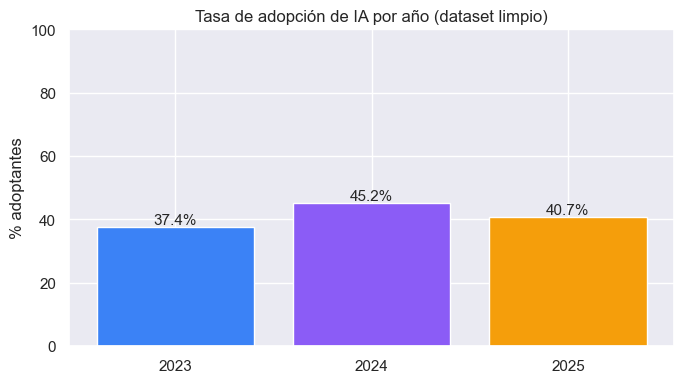

In [30]:
target_year = df.groupby('survey_year')['target'].agg(['sum', 'count', 'mean'])
target_year.columns = ['adoptantes', 'total', 'tasa']
target_year['tasa'] = (target_year['tasa'] * 100).round(1)
print('=== Adopción por año ===')
print(target_year)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(target_year.index.astype(str), target_year['tasa'], color=['#3b82f6', '#8b5cf6', '#f59e0b'])
ax.set_title('Tasa de adopción de IA por año (dataset limpio)', fontsize=12)
ax.set_ylabel('% adoptantes')
ax.set_ylim(0, 100)
for i, (_, row) in enumerate(target_year.iterrows()):
    ax.text(i, row['tasa'] + 1, f"{row['tasa']:.1f}%", ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/02_target_por_anio.png', dpi=150, bbox_inches='tight')
plt.show()


In [31]:
null_final = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_final = null_final[null_final > 0]
if len(null_final) > 0:
    print('Columnas con nulos residuales:')
    print(null_final)
else:
    print('✅ Sin nulos residuales')

numeric_expected = ['YearsCode', 'YearsCodePro', 'WorkExp', 'EdLevel', 'OrgSize', 'JobSat', 'target', 'survey_year']
for col in numeric_expected:
    if col in df.columns:
        assert pd.api.types.is_numeric_dtype(df[col]), f'{col} no es numérico'
        print(f'✅ {col}: {df[col].dtype}')


✅ Sin nulos residuales
✅ YearsCode: float64
✅ YearsCodePro: float64
✅ WorkExp: float64
✅ EdLevel: float64
✅ OrgSize: float64
✅ target: int64
✅ survey_year: int64


In [32]:
assert df.shape[0] > 0
assert df['target'].isin([0, 1]).all()
assert df.isnull().sum().sum() == 0, f'Quedan {df.isnull().sum().sum()} nulos'
print('✅ Sección 9 OK')


✅ Sección 9 OK


## Sección 10 — Exportación

El dataset preprocesado se exporta en formato Parquet, que ofrece compresión eficiente, preservación de tipos de datos y lectura rápida para los notebooks de modelado.

In [33]:
OUTPUT_PATH = '../data/df_clean.parquet'
df.to_parquet(OUTPUT_PATH, index=False)
n_rows, n_cols = df.shape
print(f'Dataset limpio exportado: {n_rows:,} filas × {n_cols} columnas')
print(f'Archivo: {OUTPUT_PATH}')


Dataset limpio exportado: 154,911 filas × 89 columnas
Archivo: ../data/df_clean.parquet


In [34]:
# Tabla resumen de columnas finales
PREFIXES = {'lang_': 'Lenguaje', 'db_': 'Base de datos', 'plat_': 'Plataforma',
            'env_': 'Entorno dev', 'Employment_': 'Employment', 'RemoteWork_': 'RemoteWork',
            'ICorPM_': 'ICorPM', 'Region_': 'Region', 'DevType_': 'DevType', 'Industry_': 'Industria'}

summary_rows = []
for col in df.columns:
    dtype = str(df[col].dtype)
    nunique = df[col].nunique()
    desc = col
    for pfx, label in PREFIXES.items():
        if col.startswith(pfx):
            desc = f'{label} = {col[len(pfx):]}'
            break
    if col == 'target':
        desc = 'Variable target binaria (adoptante IA)'
    elif col == 'survey_year':
        desc = 'Año de la encuesta'
    elif col.endswith('_count'):
        desc = f'Cantidad de items en {col.split("_")[0]}'
    summary_rows.append({'columna': col, 'dtype': dtype, 'n_unique': nunique, 'descripcion': desc})

summary_df = pd.DataFrame(summary_rows)
print(f'Columnas finales: {len(summary_df)}')
print(summary_df.to_string(index=False))


Columnas finales: 89
                                              columna   dtype  n_unique                                             descripcion
                                          survey_year   int64         3                                      Año de la encuesta
                                               target   int64         2                  Variable target binaria (adoptante IA)
                                            YearsCode float64        72                                               YearsCode
                                         YearsCodePro float64        72                                            YearsCodePro
                                              WorkExp float64        67                                                 WorkExp
                                              EdLevel float64         5                                                 EdLevel
                                              OrgSize float64         8            

In [35]:
import os
assert os.path.exists(OUTPUT_PATH)
df_check = pd.read_parquet(OUTPUT_PATH)
assert df_check.shape == df.shape
print(f'✅ Sección 10 OK — parquet verificado: {df_check.shape}')


✅ Sección 10 OK — parquet verificado: (154911, 89)
